
# CENG 467 – Mitigating Hallucinations via Epistemic Uncertainty
## Dataset Preparation & Baseline Evaluation Notebook



In [ ]:
!pip install datasets huggingface_hub -q
print("Installation complete.")

Installation complete.


## 1. Environment Setup & Google Drive

In [ ]:
from google.colab import drive #1
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/ceng467_project/data'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory ready: {SAVE_DIR}")

Mounted at /content/drive
Save directory ready: /content/drive/MyDrive/ceng467_project/data


## 2. TruthfulQA – Download & Inspection

In [ ]:
from datasets import load_dataset
import numpy as np
from collections import Counter

tqa = load_dataset('truthful_qa', 'multiple_choice')

print("Splits:", tqa.keys())
print("\nFeatures:", tqa['validation'].features)
print(f"\nTotal samples: {len(tqa['validation'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

multiple_choice/validation-00000-of-0000(…):   0%|          | 0.00/271k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

Splits: dict_keys(['validation'])

Features: {'question': Value('string'), 'mc1_targets': {'choices': List(Value('string')), 'labels': List(Value('int32'))}, 'mc2_targets': {'choices': List(Value('string')), 'labels': List(Value('int32'))}}

Total samples: 817


In [ ]:
# First print available fields
print("Available fields:", tqa['validation'].features)
print()

# Inspect first 3 samples
for i in range(3):
    sample = tqa['validation'][i]
    print(f"{'='*60}")
    print(f"Question: {sample['question']}")
    for choice, label in zip(sample['mc1_targets']['choices'], sample['mc1_targets']['labels']):
        print(f"  {'✓' if label == 1 else '✗'} {choice}")
    print()

NameError: name 'tqa' is not defined

In [ ]:
choice_counts = [len(s['mc1_targets']['choices']) for s in tqa['validation']]
print(f"Total samples: {len(tqa['validation'])}")
print(f"Choices per question — min: {min(choice_counts)}, max: {max(choice_counts)}, avg: {np.mean(choice_counts):.2f}")

# mc1 vs mc2 difference
mc2_counts = [len(s['mc2_targets']['choices']) for s in tqa['validation']]
print(f"\nmc1 (single correct): avg {np.mean(choice_counts):.2f} choices")
print(f"mc2 (multi correct) : avg {np.mean(mc2_counts):.2f} choices")

NameError: name 'tqa' is not defined

In [ ]:
import json
tqa_list = []
for s in tqa['validation']:
    tqa_list.append({
        'question': s['question'],
        'choices':  s['mc1_targets']['choices'],
        'labels':   s['mc1_targets']['labels'],  # 1 = correct, 0 = incorrect
        'correct':  s['mc1_targets']['choices'][s['mc1_targets']['labels'].index(1)]
    })

out_path = f"{SAVE_DIR}/truthfulqa_mc.json"
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(tqa_list, f, ensure_ascii=False, indent=2)

print(f"Saved → {out_path}")
print(f"Total: {len(tqa_list)} samples")

NameError: name 'tqa' is not defined

## 3. HaluEval QA – Download & Inspection

In [ ]:
import requests

url = "https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json"
local_path = f"{SAVE_DIR}/halueval_qa_raw.json"

r = requests.get(url)
r.raise_for_status()
with open(local_path, 'w', encoding='utf-8') as f:
    f.write(r.text)
print(f"Downloaded → {local_path} ({len(r.content)//1024} KB)")

Downloaded → /content/drive/MyDrive/ceng467_project/data/halueval_qa_raw.json (6019 KB)


In [ ]:
# File is JSONL format (one JSON object per line), not a JSON array
halueval_raw = []
with open(local_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            halueval_raw.append(json.loads(line))

print(f"Total samples: {len(halueval_raw)}")
print(f"Fields: {list(halueval_raw[0].keys())}")

for i in range(2):
    print(f"\n{'='*60}")
    for k, v in halueval_raw[i].items():
        print(f"  [{k}]: {str(v)[:200]}")

Total samples: 10000
Fields: ['knowledge', 'question', 'right_answer', 'hallucinated_answer']

  [knowledge]: Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magazine published by Bauer Media Group in the USA.
  [question]: Which magazine was started first Arthur's Magazine or First for Women?
  [right_answer]: Arthur's Magazine
  [hallucinated_answer]: First for Women was started first.

  [knowledge]: The Oberoi family is an Indian family that is famous for its involvement in hotels, namely through The Oberoi Group.The Oberoi Group is a hotel company with its head office in Delhi.
  [question]: The Oberoi family is part of a hotel company that has a head office in what city?
  [right_answer]: Delhi
  [hallucinated_answer]: The Oberoi family's hotel company is based in Mumbai.


In [ ]:
# No label field — dataset already separates right vs hallucinated answers
# Each sample has both: right_answer and hallucinated_answer

avg_knowledge_len = np.mean([len(s['knowledge'].split()) for s in halueval_raw])
avg_question_len  = np.mean([len(s['question'].split()) for s in halueval_raw])
avg_right_len     = np.mean([len(s['right_answer'].split()) for s in halueval_raw])
avg_halluc_len    = np.mean([len(s['hallucinated_answer'].split()) for s in halueval_raw])

print(f"Total samples       : {len(halueval_raw)}")
print(f"Avg knowledge length: {avg_knowledge_len:.1f} words")
print(f"Avg question length : {avg_question_len:.1f} words")
print(f"Avg right_answer    : {avg_right_len:.1f} words")
print(f"Avg hallucinated    : {avg_halluc_len:.1f} words")

Total samples       : 10000
Avg knowledge length: 55.4 words
Avg question length : 17.9 words
Avg right_answer    : 2.2 words
Avg hallucinated    : 11.0 words


In [ ]:
halueval_clean = []
for s in halueval_raw:
    halueval_clean.append({
        'knowledge':           s.get('knowledge', ''),
        'question':            s.get('question', ''),
        'right_answer':        s.get('right_answer', ''),
        'hallucinated_answer': s.get('hallucinated_answer', '')
    })

out_path2 = f"{SAVE_DIR}/halueval_qa_clean.json"
with open(out_path2, 'w', encoding='utf-8') as f:
    json.dump(halueval_clean, f, ensure_ascii=False, indent=2)

print(f"Saved → {out_path2}")
print(f"Total: {len(halueval_clean)} samples")

Saved → /content/drive/MyDrive/ceng467_project/data/halueval_qa_clean.json
Total: 10000 samples


In [ ]:
tqa_avg = np.mean([len(s['choices']) for s in tqa_list])

print("=" * 55)
print("SECTION 2 SUMMARY")
print("=" * 55)
print(f"\n[TruthfulQA]")
print(f"  Total samples     : {len(tqa_list)}")
print(f"  Avg. choices (mc1): {tqa_avg:.2f}")
print(f"  Format            : question + choices (list) + binary labels")
print(f"  Split             : Single split (validation), no train/test separation")
print(f"  Status            : Downloaded, converted to JSON, saved to Drive")
print(f"\n[HaluEval QA]")
print(f"  Total samples     : {len(halueval_clean)}")
print(f"  Format            : knowledge + question + right_answer + hallucinated_answer")
print(f"  Split             : No explicit split (used as evaluation set)")
print(f"  Status            : Downloaded (JSONL), parsed, saved to Drive")

SECTION 2 SUMMARY

[TruthfulQA]
  Total samples     : 817
  Avg. choices (mc1): 5.04
  Format            : question + choices (list) + binary labels
  Split             : Single split (validation), no train/test separation
  Status            : Downloaded, converted to JSON, saved to Drive

[HaluEval QA]
  Total samples     : 10000
  Format            : knowledge + question + right_answer + hallucinated_answer
  Split             : No explicit split (used as evaluation set)
  Status            : Downloaded (JSONL), parsed, saved to Drive


## 4. Baseline 1: Zero-Shot Prompting (Llama-3.1-8B via Groq)
Evaluates model accuracy on TruthfulQA MC without any consistency mechanism.
- Model: `llama-3.1-8b-instant`
- Prompt: single-turn, answer with one letter
- Result: 52.8% accuracy (431/817)

In [ ]:
import re, time

def evaluate_zero_shot_cot(sample):
    choices_text = "\n".join([f"{chr(65+i)}) {c}" for i, c in enumerate(sample['choices'])])
    correct_idx = sample['labels'].index(1)
    correct_letter = chr(65 + correct_idx)

    prompt = f"""Answer the following multiple choice question by selecting the best option.
Think step by step before giving your final answer.
At the end, write your final answer as a single letter (A, B, C, etc.).

Question: {sample['question']}

Choices:
{choices_text}

Let's think step by step."""

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0
        )
        response_text = response.choices[0].message.content.strip()

        # Extract last capital letter as predicted answer
        matches = re.findall(r'\b([A-Z])\b', response_text)
        predicted_letter = matches[-1] if matches else None

        return {
            'question':         sample['question'],
            'correct_letter':   correct_letter,
            'correct_answer':   sample['correct'],
            'predicted_letter': predicted_letter,
            'is_correct':       predicted_letter == correct_letter,
            'response':         response_text
        }
    except Exception as e:
        return {
            'question':         sample['question'],
            'correct_letter':   correct_letter,
            'correct_answer':   sample['correct'],
            'predicted_letter': None,
            'is_correct':       False,
            'response':         f"ERROR: {str(e)}"
        }

In [ ]:
!pip install groq -q #2
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 2.2 MB/s eta 0:00:00
Done.


In [ ]:
import json, re, time #3
import numpy as np
from collections import Counter
from groq import Groq

SAVE_DIR = '/content/drive/MyDrive/ceng467_project/data'

with open(f"{SAVE_DIR}/truthfulqa_mc.json", 'r', encoding='utf-8') as f:
    tqa_list = json.load(f)

print(f"Loaded {len(tqa_list)} samples.")

Loaded 817 samples.


In [ ]:
GROQ_API_KEY = "your-groq-api-key-here" #4
client = Groq(api_key=GROQ_API_KEY)
print("Groq configured.")

Groq configured.


In [ ]:
import time, re, json

results_full = []
errors = 0

for i, sample in enumerate(tqa_list):
    choices_text = "\n".join([f"{chr(65+j)}) {c}" for j, c in enumerate(sample['choices'])])
    correct_idx = sample['labels'].index(1)
    correct_letter = chr(65 + correct_idx)

    prompt = f"""Question: {sample['question']}

Choices:
{choices_text}

Respond with ONLY a single letter (A, B, C, etc.)."""

    success = False
    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=3
            )
            response_text = response.choices[0].message.content.strip()
            matches = re.findall(r'^([A-Z])', response_text)
            predicted_letter = matches[0] if matches else None
            results_full.append({
                'question':         sample['question'],
                'correct_letter':   correct_letter,
                'correct_answer':   sample['correct'],
                'predicted_letter': predicted_letter,
                'is_correct':       predicted_letter == correct_letter,
                'response':         response_text
            })
            success = True
            break
        except Exception as e:
            if '429' in str(e):
                time.sleep(45)
            else:
                break

    if not success:
        errors += 1
        results_full.append({
            'question': sample['question'], 'correct_letter': correct_letter,
            'correct_answer': sample['correct'], 'predicted_letter': None,
            'is_correct': False, 'response': "ERROR"
        })

    time.sleep(2.5)

    if (i + 1) % 50 == 0:
        correct = sum(r['is_correct'] for r in results_full)
        print(f"[{i+1}/817] Accuracy: {correct}/{i+1} = {100*correct/(i+1):.1f}% | Errors: {errors}")

correct_total = sum(r['is_correct'] for r in results_full)
print(f"\nFinal accuracy: {correct_total}/817 = {100*correct_total/817:.1f}%")

with open(f"{SAVE_DIR}/baseline1_zeroshot_cot_results.json", 'w', encoding='utf-8') as f:
    json.dump(results_full, f, ensure_ascii=False, indent=2)
print("Saved.")

[50/817] Accuracy: 26/50 = 52.0% | Errors: 7
[100/817] Accuracy: 50/100 = 50.0% | Errors: 7
[150/817] Accuracy: 79/150 = 52.7% | Errors: 7
[200/817] Accuracy: 104/200 = 52.0% | Errors: 7
[250/817] Accuracy: 131/250 = 52.4% | Errors: 7
[300/817] Accuracy: 155/300 = 51.7% | Errors: 7
[350/817] Accuracy: 184/350 = 52.6% | Errors: 7
[400/817] Accuracy: 209/400 = 52.2% | Errors: 7
[450/817] Accuracy: 238/450 = 52.9% | Errors: 7
[500/817] Accuracy: 268/500 = 53.6% | Errors: 7
[550/817] Accuracy: 292/550 = 53.1% | Errors: 7
[600/817] Accuracy: 313/600 = 52.2% | Errors: 7
[650/817] Accuracy: 341/650 = 52.5% | Errors: 7
[700/817] Accuracy: 366/700 = 52.3% | Errors: 7
[750/817] Accuracy: 392/750 = 52.3% | Errors: 7
[800/817] Accuracy: 422/800 = 52.8% | Errors: 7

Final accuracy: 431/817 = 52.8%
Saved.


## 5. Baseline 2: Self-Consistency with Majority Voting

In Baseline 1, the model produced a single deterministic answer per question (temperature=0).  
Here, we query the model **N=20 times** per question with temperature=0.7 (stochastic sampling)  
and take the **majority vote** across responses as the final prediction.

**Motivation:** If the model genuinely "knows" the answer, it will converge to the same response  
across multiple samples even under stochastic decoding. For uncertain questions, responses will  
scatter — we quantify this scatter using **Shannon entropy** over the vote distribution.

**Note:** Entropy values are computed and saved here. Baseline 3 (entropy filtering) will use  
this output directly — no second round of API calls needed.

In [ ]:
# Helper functions
# sample_single_response : single API call, returns predicted letter or None
# evaluate_self_consistency : N samples → majority vote + entropy computation

import re, time, json
import numpy as np
from collections import Counter
from groq import Groq

def sample_single_response(client, prompt, model="llama-3.1-8b-instant", temperature=0.7):
    """Single API call. Returns predicted letter (e.g. 'A') or None on failure."""
    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,
                max_tokens=3
            )
            text = response.choices[0].message.content.strip()
            matches = re.findall(r'^([A-Z])', text)
            return matches[0] if matches else None
        except Exception as e:
            if '429' in str(e):
                time.sleep(45)
            else:
                return None
    return None


def evaluate_self_consistency(sample, client, n_samples=20, temperature=0.7):
    """
    Sample N responses for a question and aggregate via majority vote.
    Also computes Shannon entropy over the vote distribution (normalized to [0,1]).

    Returns
    -------
    dict with keys:
        question, correct_letter, correct_answer,
        majority_vote, is_correct,
        votes, vote_distribution, n_valid_votes,
        entropy, normalized_entropy
    """
    choices_text   = "\n".join([f"{chr(65+i)}) {c}" for i, c in enumerate(sample['choices'])])
    correct_idx    = sample['labels'].index(1)
    correct_letter = chr(65 + correct_idx)
    n_choices      = len(sample['choices'])

    prompt = f"""Question: {sample['question']}

Choices:
{choices_text}

Respond with ONLY a single letter (A, B, C, etc.)."""

    # Collect N votes
    votes = []
    for _ in range(n_samples):
        pred = sample_single_response(client, prompt, temperature=temperature)
        if pred is not None:
            votes.append(pred)
        time.sleep(0.1)  # stay within rate limits

    # Majority vote
    majority = Counter(votes).most_common(1)[0][0] if votes else None

    # Shannon entropy (normalized)
    vote_counts   = Counter(votes)
    total         = len(votes) if votes else 1
    probs         = np.array([vote_counts.get(chr(65+i), 0) / total for i in range(n_choices)])
    probs_nonzero = probs[probs > 0]
    entropy       = -np.sum(probs_nonzero * np.log(probs_nonzero)) if len(probs_nonzero) > 0 else 0.0
    max_entropy   = np.log(n_choices) if n_choices > 1 else 1.0
    norm_entropy  = entropy / max_entropy

    return {
        'question':           sample['question'],
        'correct_letter':     correct_letter,
        'correct_answer':     sample['correct'],
        'majority_vote':      majority,
        'is_correct':         majority == correct_letter,
        'votes':              votes,
        'vote_distribution':  dict(vote_counts),
        'n_valid_votes':      len(votes),
        'entropy':            round(entropy, 4),
        'normalized_entropy': round(norm_entropy, 4),
    }

### 5.2 Run Evaluation — All 817 Samples

Progress is printed every 50 questions showing running accuracy, mean entropy, and error count.  
Results are saved to Drive after the loop completes.

In [ ]:
errors = 0

for i, sample in enumerate(tqa_list[348:], start=348):
    result = evaluate_self_consistency(sample, client, n_samples=5, temperature=0.7)
    results_sc.append(result)

    if result['majority_vote'] is None:
        errors += 1

    if (i + 1) % 50 == 0 or (i + 1) == len(tqa_list):
        correct     = sum(r['is_correct'] for r in results_sc)
        avg_entropy = np.mean([r['normalized_entropy'] for r in results_sc])
        print(f"[{i+1:4d}/{len(tqa_list)}] "
              f"Accuracy: {correct}/{i+1} = {100*correct/(i+1):.1f}% | "
              f"Avg H_norm: {avg_entropy:.3f} | "
              f"Errors: {errors}")

correct_total = sum(r['is_correct'] for r in results_sc)
print(f"\n{'='*50}")
print(f"BASELINE 2 FINAL RESULTS")
print(f"{'='*50}")
print(f"Accuracy  : {correct_total}/{len(tqa_list)} = {100*correct_total/len(tqa_list):.1f}%")
print(f"Baseline 1: 431/817 = 52.8%")
print(f"Delta     : {100*correct_total/len(tqa_list) - 52.8:+.1f}%")

out_path = f"{SAVE_DIR}/baseline2_selfconsistency_results.json"
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(results_sc, f, ensure_ascii=False, indent=2)
print(f"\nSaved → {out_path}")

[ 350/817] Accuracy: 187/350 = 53.4% | Avg H_norm: 0.111 | Errors: 0
[ 400/817] Accuracy: 212/400 = 53.0% | Avg H_norm: 0.110 | Errors: 0
[ 450/817] Accuracy: 240/450 = 53.3% | Avg H_norm: 0.111 | Errors: 0
[ 500/817] Accuracy: 272/500 = 54.4% | Avg H_norm: 0.112 | Errors: 0
[ 550/817] Accuracy: 295/550 = 53.6% | Avg H_norm: 0.112 | Errors: 0
[ 600/817] Accuracy: 317/600 = 52.8% | Avg H_norm: 0.115 | Errors: 0
[ 650/817] Accuracy: 343/650 = 52.8% | Avg H_norm: 0.115 | Errors: 0
[ 700/817] Accuracy: 368/700 = 52.6% | Avg H_norm: 0.115 | Errors: 0
[ 750/817] Accuracy: 393/750 = 52.4% | Avg H_norm: 0.114 | Errors: 0
[ 800/817] Accuracy: 424/800 = 53.0% | Avg H_norm: 0.112 | Errors: 0
[ 817/817] Accuracy: 433/817 = 53.0% | Avg H_norm: 0.111 | Errors: 0

BASELINE 2 FINAL RESULTS
Accuracy  : 433/817 = 53.0%
Baseline 1: 431/817 = 52.8%
Delta     : +0.2%

Saved → /content/drive/MyDrive/ceng467_project/data/baseline2_selfconsistency_results.json


In [ ]:
with open(f"{SAVE_DIR}/baseline2_selfconsistency_results.json", 'r', encoding='utf-8') as f:
    results_sc = json.load(f)

print(f"Loaded {len(results_sc)} results.")

Loaded 817 results.


In [ ]:
# Entropy distribution & accuracy by confidence bucket

entropies = [r['normalized_entropy'] for r in results_sc]

print(f"Entropy distribution (normalized):")
print(f"  Mean   : {np.mean(entropies):.3f}")
print(f"  Median : {np.median(entropies):.3f}")
print(f"  Std    : {np.std(entropies):.3f}")
print(f"  Min    : {np.min(entropies):.3f}")
print(f"  Max    : {np.max(entropies):.3f}")

buckets = [
    ("Low    (H < 0.3)",   lambda h: h < 0.3),
    ("Medium (0.3–0.7)",   lambda h: 0.3 <= h < 0.7),
    ("High   (H ≥ 0.7)",   lambda h: h >= 0.7),
]

print(f"\nAccuracy by entropy bucket:")
print(f"{'Bucket':<22} {'N':>5}  {'Accuracy':>10}")
print("-" * 42)
for label, cond in buckets:
    subset = [r for r in results_sc if cond(r['normalized_entropy'])]
    if subset:
        acc = sum(r['is_correct'] for r in subset) / len(subset)
        print(f"{label:<22} {len(subset):>5}  {100*acc:>9.1f}%")
    else:
        print(f"{label:<22} {0:>5}  {'N/A':>10}")

print(f"\n→ Low-entropy accuracy gap motivates entropy filtering (Baseline 3).")

Entropy distribution (normalized):
  Mean   : 0.111
  Median : 0.000
  Std    : 0.200
  Min    : -0.000
  Max    : 0.971

Accuracy by entropy bucket:
Bucket                     N    Accuracy
------------------------------------------
Low    (H < 0.3)         638       60.3%
Medium (0.3–0.7)         167       26.3%
High   (H ≥ 0.7)          12       33.3%

→ Low-entropy accuracy gap motivates entropy filtering (Baseline 3).


## 6. Baseline 3: Entropy Filtering

In Baseline 2, we observed a strong correlation between entropy and accuracy:
- Low entropy (H < 0.3): 60.3% accuracy across 638 questions
- Medium entropy (0.3–0.7): 26.3% accuracy across 167 questions

This motivates a simple filtering strategy: **only answer questions where the model is confident**
(low entropy), and abstain on uncertain ones.

We evaluate across multiple entropy thresholds to find the optimal confidence cutoff.

In [ ]:
# Entropy filtering: sweep thresholds
# For each threshold t, we "answer" only questions with normalized_entropy < t
# and measure accuracy on that subset. Coverage = fraction of questions answered.

import numpy as np
import json

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print(f"{'Threshold':<12} {'N answered':>12} {'Coverage':>10} {'Accuracy':>10}")
print("-" * 48)

filtering_results = []

for t in thresholds:
    subset = [r for r in results_sc if r['normalized_entropy'] < t]
    if subset:
        acc = sum(r['is_correct'] for r in subset) / len(subset)
        coverage = len(subset) / len(results_sc)
    else:
        acc, coverage = 0, 0

    filtering_results.append({
        'threshold': t,
        'n_answered': len(subset),
        'coverage': round(coverage, 4),
        'accuracy': round(acc, 4),
    })

    print(f"{t:<12.1f} {len(subset):>12} {100*coverage:>9.1f}% {100*acc:>9.1f}%")

print(f"\nBaseline 1 (no filtering): 52.8% | Coverage: 100%")
print(f"Baseline 2 (majority vote): 53.0% | Coverage: 100%")

# Save
out_path = f"{SAVE_DIR}/baseline3_entropy_filtering_results.json"
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(filtering_results, f, indent=2)
print(f"\nSaved → {out_path}")

Threshold      N answered   Coverage   Accuracy
------------------------------------------------
0.1                   598      73.2%      62.7%
0.2                   601      73.6%      62.6%
0.3                   638      78.1%      60.3%
0.4                   728      89.1%      55.5%
0.5                   774      94.7%      53.9%
0.6                   787      96.3%      53.9%
0.7                   805      98.5%      53.3%
0.8                   811      99.3%      53.1%
0.9                   813      99.5%      53.1%
1.0                   817     100.0%      53.0%

Baseline 1 (no filtering): 52.8% | Coverage: 100%
Baseline 2 (majority vote): 53.0% | Coverage: 100%

Saved → /content/drive/MyDrive/ceng467_project/data/baseline3_entropy_filtering_results.json


### 6.2 Accuracy vs Coverage Trade-off

As the threshold decreases, we answer fewer questions but with higher accuracy.
The table above shows this trade-off. Key question: at what threshold does filtering
provide meaningful accuracy gains while maintaining reasonable coverage?

In [ ]:
# Find optimal threshold
# Define "optimal" as highest accuracy with at least 50% coverage

candidates = [r for r in filtering_results if r['coverage'] >= 0.5]
best = max(candidates, key=lambda r: r['accuracy'])

print(f"Optimal threshold (coverage ≥ 50%): {best['threshold']}")
print(f"  Accuracy : {100*best['accuracy']:.1f}%")
print(f"  Coverage : {100*best['coverage']:.1f}% ({best['n_answered']}/{len(results_sc)} questions)")
print(f"\nComparison:")
print(f"  Baseline 1 (zero-shot)    : 52.8% | 100% coverage")
print(f"  Baseline 2 (self-consist) : 53.0% | 100% coverage")
print(f"  Baseline 3 (entropy filt) : {100*best['accuracy']:.1f}% | {100*best['coverage']:.1f}% coverage")

Optimal threshold (coverage ≥ 50%): 0.1
  Accuracy : 62.7%
  Coverage : 73.2% (598/817 questions)

Comparison:
  Baseline 1 (zero-shot)    : 52.8% | 100% coverage
  Baseline 2 (self-consist) : 53.0% | 100% coverage
  Baseline 3 (entropy filt) : 62.7% | 73.2% coverage


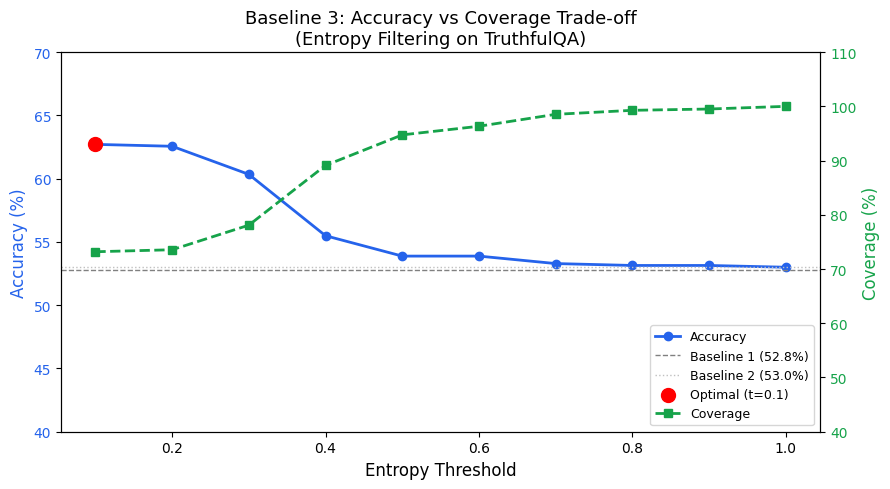

Plot saved.


In [ ]:
# Accuracy vs Coverage trade-off plot
import matplotlib.pyplot as plt

thresholds_plot = [r['threshold'] for r in filtering_results]
accuracies_plot  = [100 * r['accuracy'] for r in filtering_results]
coverages_plot   = [100 * r['coverage'] for r in filtering_results]

fig, ax1 = plt.subplots(figsize=(9, 5))

color_acc = '#2563eb'
color_cov = '#16a34a'

ax1.plot(thresholds_plot, accuracies_plot, marker='o', color=color_acc, linewidth=2, label='Accuracy')
ax1.axhline(y=52.8, color='gray', linestyle='--', linewidth=1, label='Baseline 1 (52.8%)')
ax1.axhline(y=53.0, color='silver', linestyle=':', linewidth=1, label='Baseline 2 (53.0%)')
ax1.set_xlabel('Entropy Threshold', fontsize=12)
ax1.set_ylabel('Accuracy (%)', color=color_acc, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim(40, 70)

ax2 = ax1.twinx()
ax2.plot(thresholds_plot, coverages_plot, marker='s', color=color_cov, linewidth=2, linestyle='--', label='Coverage')
ax2.set_ylabel('Coverage (%)', color=color_cov, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_cov)
ax2.set_ylim(40, 110)

# Mark optimal point
ax1.scatter([0.1], [62.7], color='red', zorder=5, s=100, label='Optimal (t=0.1)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

plt.title('Baseline 3: Accuracy vs Coverage Trade-off\n(Entropy Filtering on TruthfulQA)', fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/baseline3_accuracy_coverage.png", dpi=150)
plt.show()
print("Plot saved.")

## 7. HaluEval QA — Self-Consistency + Entropy Filtering

HaluEval is an open-ended QA dataset where each sample contains a knowledge passage,
a question, a correct answer, and a hallucinated answer.

Unlike TruthfulQA (multiple-choice), here the model generates a free-text response.
We use **semantic matching** to judge correctness: if the model's response contains
the key terms of the right answer, we count it as correct.

The same self-consistency + entropy filtering pipeline is applied:
1. Sample N=5 responses per question (temperature=0.7)
2. Check each response for correctness
3. Majority vote → final prediction
4. Compute entropy over correct/incorrect vote distribution
5. Apply entropy filtering

In [ ]:
# HaluEval evaluation functions

def check_answer_correctness(response, right_answer):
    """
    Simple lexical match: check if key terms of right_answer appear in response.
    Lowercased, stripped comparison.
    """
    if not response:
        return False
    response_lower    = response.lower().strip()
    right_lower       = right_answer.lower().strip()
    # Check if the right answer (or its key terms) appear in the response
    key_terms = [t for t in right_lower.split() if len(t) > 3]
    if not key_terms:
        return right_lower in response_lower
    matches = sum(1 for t in key_terms if t in response_lower)
    return matches / len(key_terms) >= 0.5


def sample_halueval_response(client, knowledge, question,
                              model="llama-3.1-8b-instant", temperature=0.7):
    """Single API call for HaluEval. Returns model response text or None."""
    prompt = f"""Use the following knowledge to answer the question concisely.

Knowledge: {knowledge[:500]}

Question: {question}

Answer in one sentence."""

    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,
                max_tokens=60
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            if '429' in str(e):
                time.sleep(45)
            else:
                return None
    return None


def evaluate_halueval_sample(sample, client, n_samples=5, temperature=0.7):
    """
    Sample N responses, check correctness of each, majority vote, compute entropy.
    """
    votes = []  # True/False per sample
    responses = []

    for _ in range(n_samples):
        resp = sample_halueval_response(client, sample['knowledge'], sample['question'],
                                         temperature=temperature)
        responses.append(resp)
        votes.append(check_answer_correctness(resp, sample['right_answer']))
        time.sleep(0.1)

    # Majority vote
    n_correct  = sum(votes)
    n_total    = len(votes) if votes else 1
    majority   = n_correct > n_total / 2

    # Entropy over binary distribution (correct vs incorrect)
    p_correct  = n_correct / n_total
    p_wrong    = 1 - p_correct
    probs      = [p for p in [p_correct, p_wrong] if p > 0]
    entropy    = -sum(p * np.log(p) for p in probs)
    norm_entropy = entropy / np.log(2)  # max entropy for binary = log(2)

    return {
        'question':           sample['question'],
        'right_answer':       sample['right_answer'],
        'responses':          responses,
        'votes':              votes,
        'n_correct_votes':    n_correct,
        'majority_correct':   majority,
        'entropy':            round(entropy, 4),
        'normalized_entropy': round(norm_entropy, 4),
    }

print("HaluEval functions defined.")

HaluEval functions defined.


### 7.2 Run Evaluation

We evaluate on a 200-sample subset of HaluEval (out of 10,000) for computational efficiency.
This is standard practice in hallucination mitigation research.

In [ ]:
# HaluEval evaluation loop (200 samples)

import random
random.seed(42)
halueval_subset = random.sample(halueval, 200)

results_halu = []

for i, sample in enumerate(halueval_subset):
    result = evaluate_halueval_sample(sample, client, n_samples=5, temperature=0.7)
    results_halu.append(result)

    if (i + 1) % 50 == 0 or (i + 1) == len(halueval_subset):
        correct     = sum(r['majority_correct'] for r in results_halu)
        avg_entropy = np.mean([r['normalized_entropy'] for r in results_halu])
        print(f"[{i+1:4d}/{len(halueval_subset)}] "
              f"Accuracy: {correct}/{i+1} = {100*correct/(i+1):.1f}% | "
              f"Avg H_norm: {avg_entropy:.3f}")

correct_total = sum(r['majority_correct'] for r in results_halu)
print(f"\n{'='*50}")
print(f"HALUEVAL RESULTS (Self-Consistency)")
print(f"{'='*50}")
print(f"Accuracy : {correct_total}/{len(halueval_subset)} = {100*correct_total/len(halueval_subset):.1f}%")

out_path = f"{SAVE_DIR}/halueval_selfconsistency_results.json"
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(results_halu, f, ensure_ascii=False, indent=2)
print(f"\nSaved → {out_path}")

[  50/200] Accuracy: 44/50 = 88.0% | Avg H_norm: 0.068
[ 100/200] Accuracy: 92/100 = 92.0% | Avg H_norm: 0.041
[ 150/200] Accuracy: 139/150 = 92.7% | Avg H_norm: 0.058
[ 200/200] Accuracy: 185/200 = 92.5% | Avg H_norm: 0.081

HALUEVAL RESULTS (Self-Consistency)
Accuracy : 185/200 = 92.5%

Saved → /content/drive/MyDrive/ceng467_project/data/halueval_selfconsistency_results.json


In [ ]:
# HaluEval entropy analysis

entropies_halu = [r['normalized_entropy'] for r in results_halu]

print(f"Entropy distribution (normalized):")
print(f"  Mean   : {np.mean(entropies_halu):.3f}")
print(f"  Median : {np.median(entropies_halu):.3f}")
print(f"  Std    : {np.std(entropies_halu):.3f}")

buckets = [
    ("Low    (H < 0.3)",  lambda h: h < 0.3),
    ("Medium (0.3–0.7)", lambda h: 0.3 <= h < 0.7),
    ("High   (H ≥ 0.7)",  lambda h: h >= 0.7),
]

print(f"\nAccuracy by entropy bucket:")
print(f"{'Bucket':<22} {'N':>5}  {'Accuracy':>10}")
print("-" * 42)
for label, cond in buckets:
    subset = [r for r in results_halu if cond(r['normalized_entropy'])]
    if subset:
        acc = sum(r['majority_correct'] for r in subset) / len(subset)
        print(f"{label:<22} {len(subset):>5}  {100*acc:>9.1f}%")
    else:
        print(f"{label:<22} {0:>5}  {'N/A':>10}")


Entropy distribution (normalized):
  Mean   : 0.081
  Median : 0.000
  Std    : 0.246

Accuracy by entropy bucket:
Bucket                     N    Accuracy
------------------------------------------
Low    (H < 0.3)         180       96.1%
Medium (0.3–0.7)           0         N/A
High   (H ≥ 0.7)          20       60.0%


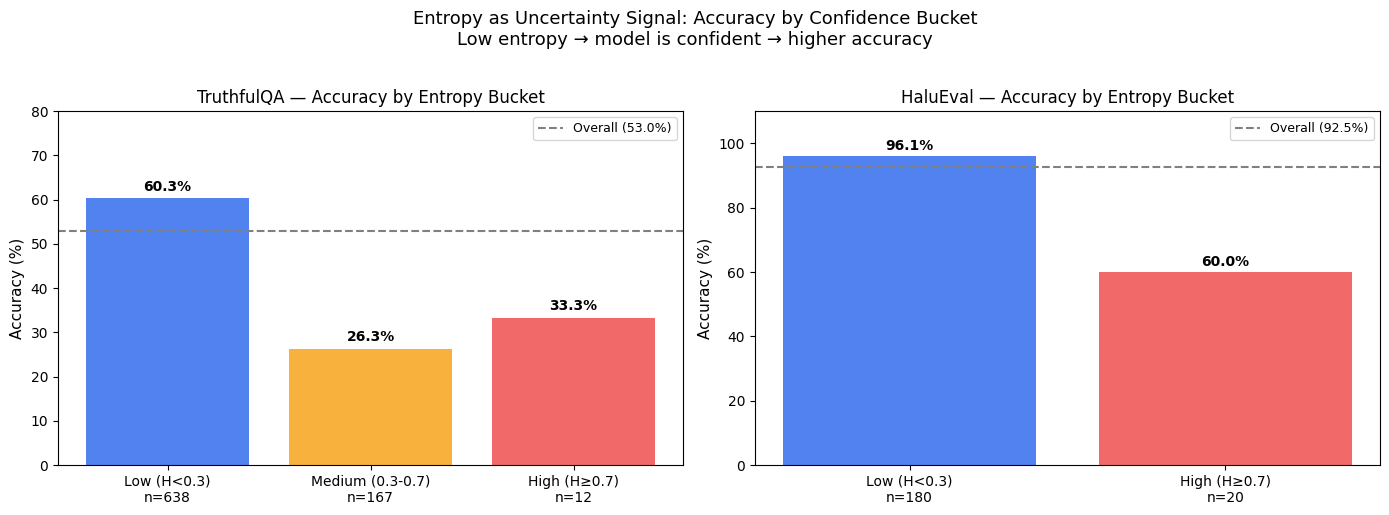

Plot saved.


In [ ]:
# HaluEval: Accuracy vs Entropy bucket plot
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: TruthfulQA entropy bucket comparison
tqa_labels   = ['Low (H<0.3)\nn=638', 'Medium (0.3-0.7)\nn=167', 'High (H≥0.7)\nn=12']
tqa_accs     = [60.3, 26.3, 33.3]
tqa_baseline = 53.0

bars = axes[0].bar(tqa_labels, tqa_accs, color=['#2563eb', '#f59e0b', '#ef4444'], alpha=0.8)
axes[0].axhline(y=tqa_baseline, color='gray', linestyle='--', linewidth=1.5, label=f'Overall ({tqa_baseline}%)')
axes[0].set_title('TruthfulQA — Accuracy by Entropy Bucket', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_ylim(0, 80)
axes[0].legend(fontsize=9)
for bar, acc in zip(bars, tqa_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: HaluEval entropy bucket comparison
halu_labels   = ['Low (H<0.3)\nn=180', 'High (H≥0.7)\nn=20']
halu_accs     = [96.1, 60.0]
halu_baseline = 92.5

bars2 = axes[1].bar(halu_labels, halu_accs, color=['#2563eb', '#ef4444'], alpha=0.8)
axes[1].axhline(y=halu_baseline, color='gray', linestyle='--', linewidth=1.5, label=f'Overall ({halu_baseline}%)')
axes[1].set_title('HaluEval — Accuracy by Entropy Bucket', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)
for bar, acc in zip(bars2, halu_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Entropy as Uncertainty Signal: Accuracy by Confidence Bucket\n'
             'Low entropy → model is confident → higher accuracy',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/entropy_bucket_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## Additional Evaluation Metrics

Accuracy and coverage alone do not establish that entropy is a *statistically reliable* correctness predictor, nor whether it is *well calibrated*. We add three standard metrics from the uncertainty-quantification literature:

1. **AUROC** — does entropy discriminate correct from incorrect responses?
2. **Precision / Recall / F1** — framing entropy filtering (t=0.1) as a binary classifier
3. **Expected Calibration Error (ECE)** — is `1 - normalized_entropy` a well-calibrated confidence score?

These are computed directly from `results_sc` (TruthfulQA) and `results_halu` (HaluEval), no new API calls needed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score

In [ ]:
# Load results_sc and results_halu from saved JSON files
# (skip if these variables already exist in memory from earlier cells in this session)
import json

with open(f"{SAVE_DIR}/baseline2_selfconsistency_results.json", 'r', encoding='utf-8') as f:
    results_sc = json.load(f)

with open(f"{SAVE_DIR}/halueval_selfconsistency_results.json", 'r', encoding='utf-8') as f:
    results_halu = json.load(f)

print(f"Loaded results_sc   : {len(results_sc)} samples")
print(f"Loaded results_halu : {len(results_halu)} samples")

Loaded results_sc   : 817 samples
Loaded results_halu : 200 samples


In [ ]:
# AUROC: Can entropy discriminate correct from incorrect responses?
# Score = -normalized_entropy (low entropy -> high score -> predicts correct)

from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score

# TruthfulQA
y_true_tqa  = [1 if r['is_correct'] else 0 for r in results_sc]
y_score_tqa = [-r['normalized_entropy'] for r in results_sc]
auroc_tqa   = roc_auc_score(y_true_tqa, y_score_tqa)

# HaluEval
y_true_halu  = [1 if r['majority_correct'] else 0 for r in results_halu]
y_score_halu = [-r['normalized_entropy'] for r in results_halu]
auroc_halu   = roc_auc_score(y_true_halu, y_score_halu)

print(f"{'Dataset':<12}{'N':>6}{'N Correct':>12}{'AUROC':>10}")
print("-" * 40)
print(f"{'TruthfulQA':<12}{len(y_true_tqa):>6}{sum(y_true_tqa):>12}{auroc_tqa:>10.3f}")
print(f"{'HaluEval':<12}{len(y_true_halu):>6}{sum(y_true_halu):>12}{auroc_halu:>10.3f}")
print(f"\nRandom baseline AUROC = 0.500. Both datasets exceed this, confirming entropy carries genuine signal.")

Dataset          N   N Correct     AUROC
----------------------------------------
TruthfulQA     817         433     0.640
HaluEval       200         185     0.735

Random baseline AUROC = 0.500. Both datasets exceed this, confirming entropy carries genuine signal.


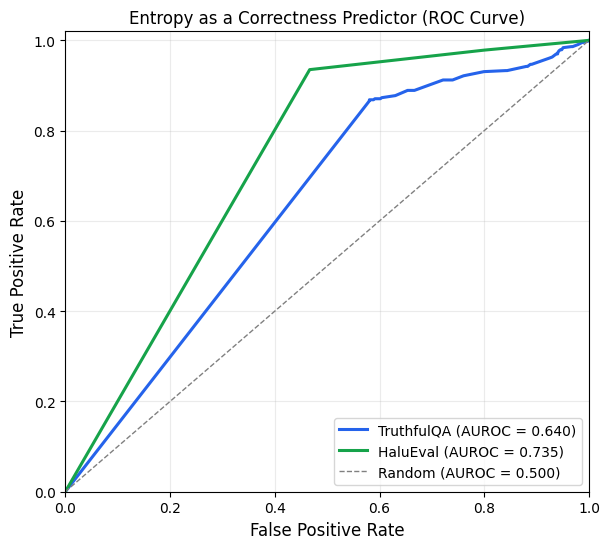

In [ ]:
# ROC curve plot
fpr_tqa, tpr_tqa, _   = roc_curve(y_true_tqa, y_score_tqa)
fpr_halu, tpr_halu, _ = roc_curve(y_true_halu, y_score_halu)

fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.plot(fpr_tqa, tpr_tqa, color='#2563eb', linewidth=2.2, label=f'TruthfulQA (AUROC = {auroc_tqa:.3f})')
ax.plot(fpr_halu, tpr_halu, color='#16a34a', linewidth=2.2, label=f'HaluEval (AUROC = {auroc_halu:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random (AUROC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Entropy as a Correctness Predictor (ROC Curve)', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/auroc_curve.png", dpi=200)
plt.show()

In [ ]:
# Precision / Recall / F1 of the entropy-based abstention decision at t=0.1
# Framing: predicted "trustworthy/answer" = (normalized_entropy < t)
# Ground truth: is_correct / majority_correct

import numpy as np

t = 0.1

y_pred_tqa = np.array([1 if r['normalized_entropy'] < t else 0 for r in results_sc])
precision_tqa = precision_score(y_true_tqa, y_pred_tqa, zero_division=0)
recall_tqa    = recall_score(y_true_tqa, y_pred_tqa, zero_division=0)
f1_tqa        = f1_score(y_true_tqa, y_pred_tqa, zero_division=0)

y_pred_halu = np.array([1 if r['normalized_entropy'] < t else 0 for r in results_halu])
precision_halu = precision_score(y_true_halu, y_pred_halu, zero_division=0)
recall_halu    = recall_score(y_true_halu, y_pred_halu, zero_division=0)
f1_halu        = f1_score(y_true_halu, y_pred_halu, zero_division=0)

print(f"Entropy-filtering as binary classifier (t={t}):\n")
print(f"{'Dataset':<12}{'Precision':>12}{'Recall':>10}{'F1':>8}")
print("-" * 42)
print(f"{'TruthfulQA':<12}{precision_tqa:>12.3f}{recall_tqa:>10.3f}{f1_tqa:>8.3f}")
print(f"{'HaluEval':<12}{precision_halu:>12.3f}{recall_halu:>10.3f}{f1_halu:>8.3f}")

Entropy-filtering as binary classifier (t=0.1):

Dataset        Precision    Recall      F1
------------------------------------------
TruthfulQA         0.627     0.866   0.727
HaluEval           0.961     0.935   0.948


In [ ]:
# Expected Calibration Error (ECE)
# Confidence = 1 - normalized_entropy. We bin by confidence and compare
# average confidence vs. observed accuracy in each bin.

def compute_ece(confidences, corrects, n_bins=10):
    confidences = np.array(confidences)
    corrects = np.array(corrects, dtype=float)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n_total = len(confidences)
    bin_centers, accs, counts = [], [], []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (confidences >= lo) & (confidences <= hi) if i == n_bins - 1 else (confidences >= lo) & (confidences < hi)
        n_in_bin = mask.sum()
        bin_centers.append((lo + hi) / 2)
        if n_in_bin > 0:
            avg_conf = confidences[mask].mean()
            avg_acc  = corrects[mask].mean()
            ece += (n_in_bin / n_total) * abs(avg_conf - avg_acc)
            accs.append(avg_acc)
        else:
            accs.append(np.nan)
        counts.append(n_in_bin)
    return ece, np.array(bin_centers), np.array(accs), np.array(counts)

conf_tqa    = [1 - r['normalized_entropy'] for r in results_sc]
correct_tqa = [1 if r['is_correct'] else 0 for r in results_sc]
ece_tqa, centers_tqa, accs_tqa, counts_tqa = compute_ece(conf_tqa, correct_tqa)

conf_halu    = [1 - r['normalized_entropy'] for r in results_halu]
correct_halu = [1 if r['majority_correct'] else 0 for r in results_halu]
ece_halu, centers_halu, accs_halu, counts_halu = compute_ece(conf_halu, correct_halu)

print(f"Expected Calibration Error (ECE), 10 bins:\n")
print(f"  TruthfulQA : {ece_tqa:.4f}  ({'well calibrated' if ece_tqa < 0.1 else 'poorly calibrated'})")
print(f"  HaluEval   : {ece_halu:.4f}  ({'well calibrated' if ece_halu < 0.1 else 'poorly calibrated'})")

Expected Calibration Error (ECE), 10 bins:

  TruthfulQA : 0.3669  (poorly calibrated)
  HaluEval   : 0.0759  (well calibrated)


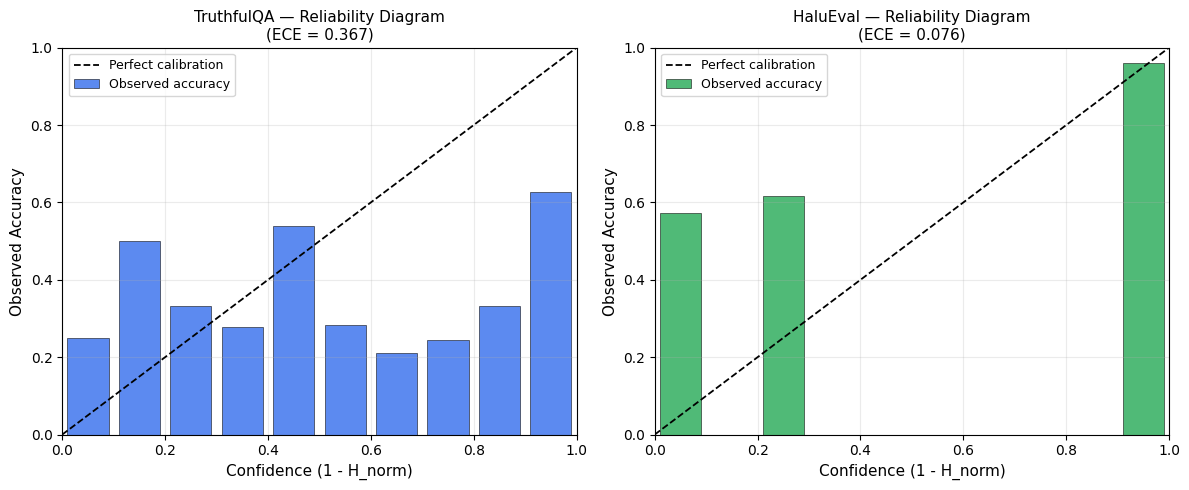

In [ ]:
# Reliability diagrams (calibration plots)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
width = 0.08

ax = axes[0]
mask = ~np.isnan(accs_tqa)
ax.bar(centers_tqa[mask], accs_tqa[mask], width=width, color='#2563eb', alpha=0.75, edgecolor='black', linewidth=0.5, label='Observed accuracy')
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.3, label='Perfect calibration')
ax.set_xlabel('Confidence (1 - H_norm)', fontsize=11)
ax.set_ylabel('Observed Accuracy', fontsize=11)
ax.set_title(f'TruthfulQA — Reliability Diagram\n(ECE = {ece_tqa:.3f})', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.25)

ax = axes[1]
mask = ~np.isnan(accs_halu)
ax.bar(centers_halu[mask], accs_halu[mask], width=width, color='#16a34a', alpha=0.75, edgecolor='black', linewidth=0.5, label='Observed accuracy')
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.3, label='Perfect calibration')
ax.set_xlabel('Confidence (1 - H_norm)', fontsize=11)
ax.set_ylabel('Observed Accuracy', fontsize=11)
ax.set_title(f'HaluEval — Reliability Diagram\n(ECE = {ece_halu:.3f})', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/calibration_diagram.png", dpi=200)
plt.show()

In [ ]:
from google.colab import files
files.download(f"{SAVE_DIR}/auroc_curve.png")
files.download(f"{SAVE_DIR}/calibration_diagram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download(f"{SAVE_DIR}/baseline3_accuracy_coverage.png")
files.download(f"{SAVE_DIR}/entropy_bucket_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Extended Analysis: Post-hoc Calibration (Temperature Scaling)

Section above showed `1 - normalized_entropy` is poorly calibrated as a confidence score on TruthfulQA (ECE = 0.367). Here we apply **temperature scaling**, a standard post-hoc calibration method: we fit a single scalar $T$ by minimizing negative log-likelihood (NLL) on the binary correctness labels, then rescale confidence as $\text{sigmoid}(\text{logit}(c) / T)$.

This does not require any new API calls — it operates entirely on the existing `results_sc` / `results_halu` entropy values.

In [ ]:
# Temperature scaling: fit T by minimizing NLL on existing confidence scores
from scipy.optimize import minimize_scalar

def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def nll_loss(T, confidences, corrects):
    logits = logit(confidences)
    scaled = sigmoid(logits / T)
    scaled = np.clip(scaled, 1e-6, 1 - 1e-6)
    return -np.mean(corrects * np.log(scaled) + (1 - corrects) * np.log(1 - scaled))

def fit_temperature(confidences, corrects, bounds=(0.05, 100.0)):
    confidences = np.array(confidences)
    corrects = np.array(corrects, dtype=float)
    result = minimize_scalar(lambda T: nll_loss(T, confidences, corrects), bounds=bounds, method='bounded')
    return result.x, result.fun

# Fit on TruthfulQA (conf_tqa, correct_tqa, ece_tqa already defined in the ECE cell above)
T_tqa, nll_tqa = fit_temperature(conf_tqa, correct_tqa)
conf_tqa_cal = sigmoid(logit(np.array(conf_tqa)) / T_tqa)
ece_after_tqa, _, _, _ = compute_ece(conf_tqa_cal, correct_tqa)

# Fit on HaluEval
T_halu, nll_halu = fit_temperature(conf_halu, correct_halu)
conf_halu_cal = sigmoid(logit(np.array(conf_halu)) / T_halu)
ece_after_halu, _, _, _ = compute_ece(conf_halu_cal, correct_halu)

print(f"{'Dataset':<12}{'T':>8}{'ECE before':>12}{'ECE after':>12}{'Reduction':>12}")
print("-" * 56)
print(f"{'TruthfulQA':<12}{T_tqa:>8.2f}{ece_tqa:>12.4f}{ece_after_tqa:>12.4f}{100*(ece_tqa-ece_after_tqa)/ece_tqa:>11.1f}%")
print(f"{'HaluEval':<12}{T_halu:>8.2f}{ece_halu:>12.4f}{ece_after_halu:>12.4f}{100*(ece_halu-ece_after_halu)/ece_halu:>11.1f}%")

Dataset            T  ECE before   ECE after   Reduction
--------------------------------------------------------
TruthfulQA     27.23      0.3669      0.0660       82.0%
HaluEval        4.43      0.0759      0.0232       69.5%


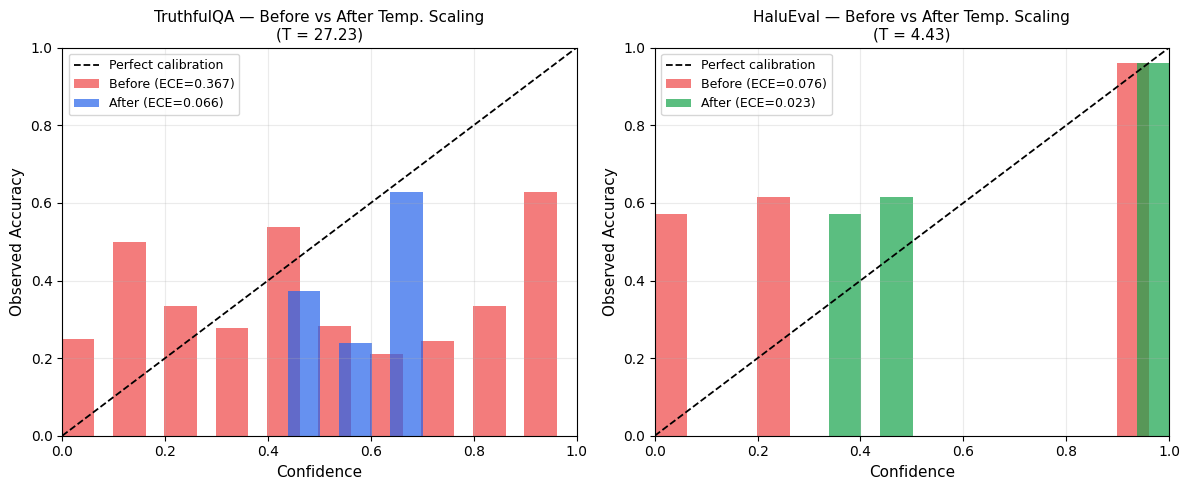

In [ ]:
# Before/after calibration plot
def compute_ece_bins(confidences, corrects, n_bins=10):
    confidences = np.array(confidences)
    corrects = np.array(corrects, dtype=float)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers, accs = [], []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (confidences >= lo) & (confidences <= hi) if i == n_bins-1 else (confidences >= lo) & (confidences < hi)
        n_in_bin = mask.sum()
        bin_centers.append((lo + hi) / 2)
        accs.append(corrects[mask].mean() if n_in_bin > 0 else np.nan)
    return np.array(bin_centers), np.array(accs)

centers_tqa_b, accs_tqa_b = compute_ece_bins(conf_tqa, correct_tqa)
centers_tqa_a, accs_tqa_a = compute_ece_bins(conf_tqa_cal, correct_tqa)
centers_halu_b, accs_halu_b = compute_ece_bins(conf_halu, correct_halu)
centers_halu_a, accs_halu_a = compute_ece_bins(conf_halu_cal, correct_halu)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
width = 0.08

ax = axes[0]
mask = ~np.isnan(accs_tqa_b)
ax.bar(centers_tqa_b[mask] - 0.02, accs_tqa_b[mask], width=width*0.8, color='#ef4444', alpha=0.7, label=f'Before (ECE={ece_tqa:.3f})')
mask2 = ~np.isnan(accs_tqa_a)
ax.bar(centers_tqa_a[mask2] + 0.02, accs_tqa_a[mask2], width=width*0.8, color='#2563eb', alpha=0.7, label=f'After (ECE={ece_after_tqa:.3f})')
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.3, label='Perfect calibration')
ax.set_xlabel('Confidence', fontsize=11); ax.set_ylabel('Observed Accuracy', fontsize=11)
ax.set_title(f'TruthfulQA — Before vs After Temp. Scaling\n(T = {T_tqa:.2f})', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.25)

ax = axes[1]
mask = ~np.isnan(accs_halu_b)
ax.bar(centers_halu_b[mask] - 0.02, accs_halu_b[mask], width=width*0.8, color='#ef4444', alpha=0.7, label=f'Before (ECE={ece_halu:.3f})')
mask2 = ~np.isnan(accs_halu_a)
ax.bar(centers_halu_a[mask2] + 0.02, accs_halu_a[mask2], width=width*0.8, color='#16a34a', alpha=0.7, label=f'After (ECE={ece_after_halu:.3f})')
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.3, label='Perfect calibration')
ax.set_xlabel('Confidence', fontsize=11); ax.set_ylabel('Observed Accuracy', fontsize=11)
ax.set_title(f'HaluEval — Before vs After Temp. Scaling\n(T = {T_halu:.2f})', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/temperature_scaling_calibration.png", dpi=200)
plt.show()

In [ ]:
from google.colab import files
files.download(f"{SAVE_DIR}/temperature_scaling_calibration.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Extended Analysis: Semantic Clustering of Entropy (HaluEval)

Our main entropy computation uses a **syntactic** majority vote: for HaluEval, each of the 5 sampled responses is scored independently as correct/incorrect via lexical matching, and entropy is computed over this binary correct/incorrect split. This conflates two distinct sources of variance: (1) genuine disagreement about the *content* of the answer, and (2) surface-form paraphrasing of the *same* answer (e.g., "guest vocalist" vs. "featured vocalist").

Kuhn et al. (2023) propose **semantic entropy**: cluster responses by *meaning* (via sentence embeddings) rather than exact match, before computing entropy. This is only meaningful for HaluEval's open-ended generation — TruthfulQA already constrains the model to a single letter, so there is no surface-form variation to cluster.

We apply this to the 200 HaluEval samples already collected in `results_halu`, using each sample's 5 raw `responses`. **No new API calls are needed.**

In [ ]:
# Install sentence-transformers for semantic embeddings (if not already available)
!pip install -q sentence-transformers

In [ ]:
# Semantic clustering of HaluEval responses
# For each sample, embed its 5 responses, cluster by cosine distance,
# then compute entropy over the CLUSTER distribution instead of raw text matches.

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from collections import Counter

embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Embedding model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [ ]:
def semantic_entropy(responses, distance_threshold=0.3):
    """
    Cluster a list of text responses by semantic similarity (cosine distance
    on sentence embeddings), then compute normalized Shannon entropy over
    the resulting cluster-size distribution.
    """
    valid_responses = [r for r in responses if r]
    n = len(valid_responses)
    if n <= 1:
        return 0.0, 1

    embeddings = embed_model.encode(valid_responses)

    clustering = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=distance_threshold,
        metric='cosine',
        linkage='average'
    )
    labels = clustering.fit_predict(embeddings)
    n_clusters = len(set(labels))

    counts = Counter(labels)
    probs = np.array([c / n for c in counts.values()])
    entropy = -np.sum(probs * np.log(probs))
    max_entropy = np.log(n) if n > 1 else 1.0
    norm_entropy = entropy / max_entropy

    return norm_entropy, n_clusters


# Apply to all 200 HaluEval samples
semantic_entropies = []
n_clusters_list = []

for i, r in enumerate(results_halu):
    sem_h, n_clust = semantic_entropy(r['responses'])
    semantic_entropies.append(sem_h)
    n_clusters_list.append(n_clust)
    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/200")

print(f"\nDone. Mean clusters per sample: {np.mean(n_clusters_list):.2f} (out of 5 responses)")

  Processed 50/200
  Processed 100/200
  Processed 150/200
  Processed 200/200

Done. Mean clusters per sample: 1.07 (out of 5 responses)


In [ ]:
# Compare syntactic vs semantic entropy on HaluEval
from sklearn.metrics import roc_auc_score

syntactic_entropies = [r['normalized_entropy'] for r in results_halu]
y_true_halu_sem = [1 if r['majority_correct'] else 0 for r in results_halu]

auroc_syntactic = roc_auc_score(y_true_halu_sem, [-h for h in syntactic_entropies])
auroc_semantic   = roc_auc_score(y_true_halu_sem, [-h for h in semantic_entropies])

print("Syntactic vs. Semantic Entropy — AUROC comparison (HaluEval)")
print("=" * 60)
print(f"Syntactic entropy AUROC : {auroc_syntactic:.4f}")
print(f"Semantic entropy AUROC  : {auroc_semantic:.4f}")
print(f"Mean clusters/sample    : {np.mean(n_clusters_list):.2f} / 5")
print(f"\nCorrelation (syntactic vs semantic): {np.corrcoef(syntactic_entropies, semantic_entropies)[0,1]:.3f}")

Syntactic vs. Semantic Entropy — AUROC comparison (HaluEval)
Syntactic entropy AUROC : 0.7350
Semantic entropy AUROC  : 0.4973
Mean clusters/sample    : 1.07 / 5

Correlation (syntactic vs semantic): 0.342


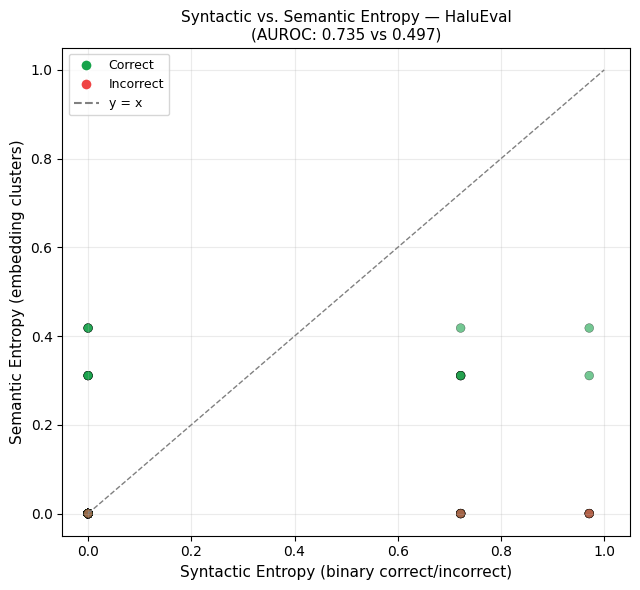

In [ ]:
# Visualize: syntactic vs semantic entropy scatter, colored by correctness
fig, ax = plt.subplots(figsize=(6.5, 6))

colors = ['#16a34a' if c else '#ef4444' for c in y_true_halu_sem]
ax.scatter(syntactic_entropies, semantic_entropies, c=colors, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='y = x')
ax.set_xlabel('Syntactic Entropy (binary correct/incorrect)', fontsize=11)
ax.set_ylabel('Semantic Entropy (embedding clusters)', fontsize=11)
ax.set_title(f'Syntactic vs. Semantic Entropy — HaluEval\n(AUROC: {auroc_syntactic:.3f} vs {auroc_semantic:.3f})', fontsize=11)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#16a34a', markersize=8, label='Correct'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444', markersize=8, label='Incorrect'),
    Line2D([0], [0], color='gray', linestyle='--', label='y = x')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/semantic_vs_syntactic_entropy.png", dpi=200)
plt.show()

In [ ]:
from google.colab import files
files.download(f"{SAVE_DIR}/semantic_vs_syntactic_entropy.png")

# Also save the numeric results for the report
import json as j
semantic_clustering_summary = {
    'auroc_syntactic': float(auroc_syntactic),
    'auroc_semantic': float(auroc_semantic),
    'mean_clusters_per_sample': float(np.mean(n_clusters_list)),
    'correlation_syntactic_semantic': float(np.corrcoef(syntactic_entropies, semantic_entropies)[0,1])
}
with open(f"{SAVE_DIR}/semantic_clustering_summary.json", 'w') as f:
    j.dump(semantic_clustering_summary, f, indent=2)
files.download(f"{SAVE_DIR}/semantic_clustering_summary.json")
print(semantic_clustering_summary)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{'auroc_syntactic': 0.734954954954955, 'auroc_semantic': 0.4972972972972973, 'mean_clusters_per_sample': 1.07, 'correlation_syntactic_semantic': 0.34150026788953874}
